# Plot whole-band CWT scalograms

Plot whole-band CWT scalograms for selected channels of a single subject run.

Reads the scalogram dataset written by the tcp_cwt pipeline:
    `cwt/whole-band/scalogram`  — shape `[n_channels, n_scales, n_timepoints]`, float64

Each row in the stored matrix corresponds to a scale derived from a log-spaced
frequency grid (0.008–0.5 Hz), so row 0 is the lowest frequency and the last row
is the highest. The scale axis is converted to Hz for readability.

In [17]:
import os
import sys
from pathlib import Path

from lib.fs.project_config import REPO_ROOT

import h5py
import numpy as np

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

import plot_config  # noqa: F401

In [18]:
# ---------------------------------------------------------------------------
# Parameters matching the tcp_cwt scale grid (must stay in sync with lib.rs)
# ---------------------------------------------------------------------------
TR = 0.8        # repetition time in seconds
W0 = 6.0        # Morlet center frequency
F_MIN = 0.008   # Hz — lower bound of scale grid
F_MAX = 0.5     # Hz — upper bound of scale grid

# ---------------------------------------------------------------------------
# Subject / run
# ---------------------------------------------------------------------------
subject_id = "sub-NDARINVAG388HJL"
file_name = f"{subject_id}_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc"
print(file_name)
params = {pair.split('-', 1)[0]: pair.split('-', 1)[1] 
             for pair in file_name.split('_')}

preprocessing_dir = Path("/Users/ipeglin/Documents/masters_thesis/bids_processed_consolidated_data")
h5_path = preprocessing_dir / subject_id / f"{file_name}_bold.h5"

# Channel indices to plot (0-based into the concatenated cortical+subcortical array)
channels_to_plot = [0, 1]

sub-NDARINVAG388HJL_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc


In [19]:
# ---------------------------------------------------------------------------
# Load scalogram
# ---------------------------------------------------------------------------
with h5py.File(h5_path, "r") as f:
    scalogram = f["03cwt/full_run_std"][:]  # [n_channels, n_scales, n_timepoints]

n_channels, n_scales, n_timepoints = scalogram.shape
time_axis = np.arange(n_timepoints) * TR  # seconds

# Reconstruct the frequency axis: same log-spacing used when building scales
FREQ_AXIS = F_MIN * (F_MAX / F_MIN) ** (np.arange(n_scales) / (n_scales - 1))

print(f"Scalogram shape: {scalogram.shape}")
print(f"  channels={n_channels}, scales={n_scales}, timepoints={n_timepoints}")

Scalogram shape: (432, 224, 488)
  channels=432, scales=224, timepoints=488


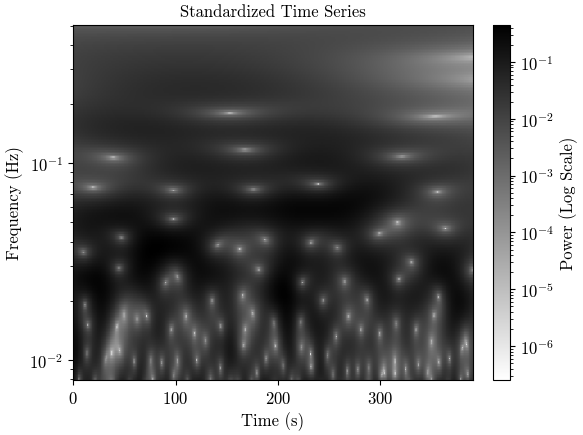

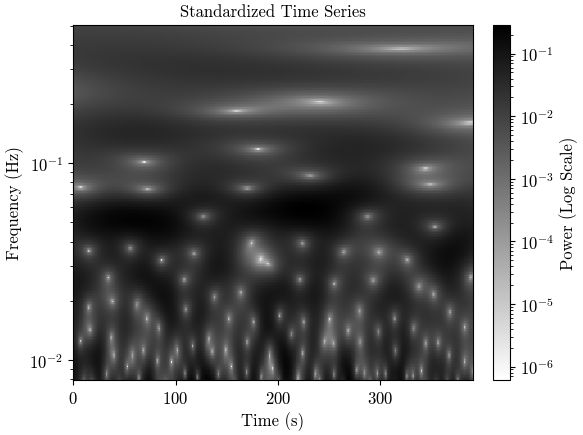

In [20]:
# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
include_params = ["sub", "task"]
cmap = 'gray_r'

for ch in channels_to_plot:
  power_std = scalogram[ch]    # [n_scales, n_timepoints]

  vmin_std = power_std[power_std > 0].min() if len(power_std[power_std > 0]) > 0 else 1e-10
  norm_std = mcolors.LogNorm(vmin=vmin_std, vmax=power_std.max())

  mesh_std = plt.pcolormesh(
      time_axis, FREQ_AXIS, power_std,
      shading="auto", cmap=cmap, norm=norm_std,
  )
  plt.yscale("log")
  plt.xlabel("Time (s)")
  plt.ylabel("Frequency (Hz)")
  plt.title(f"Standardized Time Series")
  plt.colorbar(mesh_std, label="Power (Log Scale)")

  plt.show()